In [1]:
# these packages are needed for the generator to work
import torch
import torch.nn as nn
# these packages are needed for the image generation function
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import numpy as np

In [2]:
USE_EXCITATION_QUALITY_IN_C = True
MASK_SOLITON_X_WITH_VALID = True
NUM_CLASSES = 3
PREVIEW_PER_CLASS = 5
LATENT_DIM = 128
COND_DIM = 6
EMBED_DIM = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FIXED_Z_BY_CLASS = {
    cls: torch.randn(PREVIEW_PER_CLASS, LATENT_DIM, device=DEVICE)
    for cls in range(NUM_CLASSES)
}

In [3]:
class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int,
        cond_dim: int,
        embed_dim: int,
        base_channels: int = 128,
    ):
        super().__init__()

        self.cond_embed = nn.Sequential(
            nn.Linear(cond_dim, embed_dim),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.init_h = 33
        self.init_w = 41
        self.init_channels = base_channels

        self.fc = nn.Linear(latent_dim + embed_dim,
                            base_channels * self.init_h * self.init_w)

        self.net = nn.Sequential(
            # (B, C, 41, 33)
            nn.ConvTranspose2d(base_channels, base_channels // 2,
                               kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(base_channels // 2),
            nn.LeakyReLU(0.2, inplace=True),

            # (B, C/2, 82, 66)
            nn.ConvTranspose2d(base_channels // 2, base_channels // 4,
                               kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(base_channels // 4),
            nn.LeakyReLU(0.2, inplace=True),

            # (B, C/4, 164, 132)
            nn.Conv2d(base_channels // 4, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z: torch.Tensor, cond: torch.Tensor):
        cond_feat = self.cond_embed(cond)
        x = torch.cat([z, cond_feat], dim=1)

        x = self.fc(x)
        x = x.view(x.size(0), self.init_channels, self.init_h, self.init_w)

        img = self.net(x)
        return img

In [8]:
g = Generator(LATENT_DIM,COND_DIM,EMBED_DIM).to(DEVICE)

ckpt = torch.load("./cgan_100.pt", map_location=DEVICE)

g.load_state_dict(ckpt["g_state"])

g.to(DEVICE)

g.eval()

FileNotFoundError: [Errno 2] No such file or directory: './cgan_100.pt'

In [7]:
def make_condition_tensor(
    class_idx: int,
    position: float = 0.0,
    valid_excitation: Optional[float] = None,
    quality: float = 1.0,
    batch_size: int = 1,
    device: Optional[torch.device] = None,
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    if class_idx not in {0, 1, 2}:
        raise ValueError(f"class_idx must be one of {{0,1,2}}, got {class_idx}")

    if valid_excitation is None:
        valid_excitation = 1.0 if class_idx == 1 else 0.0

    c = torch.zeros((batch_size, COND_DIM), dtype=dtype, device=device)
    c[:, class_idx] = 1.0
    c[:, 3] = float(np.clip(position, -1.0, 1.0))
    c[:, 4] = 1.0 if float(valid_excitation) >= 0.5 else 0.0
    c[:, 5] = float(np.clip(quality, 0.0, 1.0))

    if MASK_SOLITON_X_WITH_VALID:
        c[:, 3] = c[:, 3] * c[:, 4]
    if not USE_EXCITATION_QUALITY_IN_C:
        c[:, 5] = 0.0

    return c

In [5]:
@torch.no_grad()
def generate_single_sample(
    g: nn.Module,
    label: int,
    position: float = 0.0,
    quality: float = 1.0,
    seed: int | None = None,
):
    # optional reproducibility
    if seed is not None:
        gen = torch.Generator(device=DEVICE).manual_seed(int(seed))
        z = torch.randn(1, LATENT_DIM, generator=gen, device=DEVICE)
    else:
        z = torch.randn(1, LATENT_DIM, device=DEVICE)

    # only class 1 has a valid soliton position
    cond = make_condition_tensor(
        class_idx=int(label),
        position=position if label == 1 else 0.0,
        valid_excitation=(1.0 if int(label) == 1 else 0.0),
        quality=quality,
        device=DEVICE,
    )

    # generate image
    img = g(z, cond)[0, 0].detach().cpu().numpy()
    img = ((img + 1.0) * 127.5).clip(0, 255).astype(np.uint8)

    # also return condition as numpy for convenience
    cond_np = cond[0].detach().cpu().numpy()

    return img, cond_np

In [6]:
img, condition = generate_single_sample(g, 1, 0.1)

NameError: name 'make_condition_tensor' is not defined

In [14]:
import matplotlib.pyplot as plt

def plot_generated_sample(img: np.ndarray, cond: np.ndarray):
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Condition: {cond}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

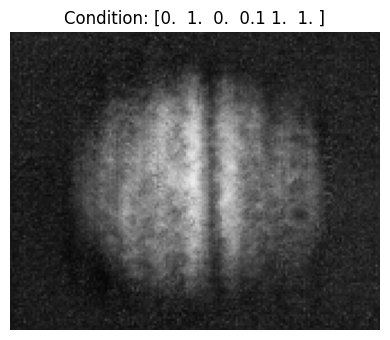

In [15]:
plot_generated_sample(img, condition)